# LOAD LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
from datetime import datetime
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet
import os
import sys
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.config import PERIOD_START, PERIOD_END, select_period
from src.gapfilling_utils import (
    setup_log_transform,
    undersample_target,
    learn_gap_dist,
    create_artificial_gap_splits,
    plot_cv_splits
)

# CONFIGURATION

In [2]:
START_DATE, END_DATE = PERIOD_START, PERIOD_END  # dataset period, see src/config.py
TARGET_FLUX = 'FN2O'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
N_FOLDS = 10
PARCEL_CERTAIN = True # choose if to use in the training also values coming from mixed contribution
LOG_TRANSFORM = False
UNDERSAMPLE = False
ADD_TRT = True

# LOAD DATA

In [3]:
data_main = fluxes = load_parquet(filepath=r"82.1.1_GapFillingDataset.parquet")
data_main = select_period(data_main, timestamp='middle')
print(f"\nUsing data from {START_DATE} to {END_DATE}")
TARGET = f"{TARGET_FLUX}_L3.3_CUT_50_QCF0"
print(f"\nTarget column: {TARGET}")

data_main

Loaded .parquet file 82.1.1_GapFillingDataset.parquet (0.077 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
select_period: kept 13776 of 13776 records (2024-08-22 00:15:00 to 2025-06-04 23:45:00, timestamp=middle)

Using data from 2024-08-22 00:00:00 to 2025-06-05 00:00:00

Target column: FN2O_L3.3_CUT_50_QCF0


,NEE_L3.3_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,FN2O_L3.3_CUT_16_QCF,FN2O_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_84_QCF,FN2O_L3.3_CUT_16_QCF0,FN2O_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FN2O_RANDUNC_HF,SW_IN_POT,prec,ta,...,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,can_height,cropN,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-08-22 00:15:00,4.791627,0.475098,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,0.461859,0.0,0.000,11.276667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,0
2024-08-22 00:45:00,4.565958,0.662601,0.365031,0.365031,NaN,NaN,NaN,NaN,A,certain,0.0,0.779504,0.0,0.000,11.043333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,1
2024-08-22 01:15:00,4.673149,0.530312,NaN,NaN,NaN,NaN,NaN,NaN,B,uncertain,1.0,0.107261,0.0,0.000,10.890000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,2
2024-08-22 01:45:00,4.323735,0.851883,1.399927,NaN,NaN,1.399927,NaN,NaN,A,certain,0.0,0.457078,0.0,0.000,10.720000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,3
2024-08-22 02:15:00,4.323735,0.868263,NaN,NaN,NaN,NaN,NaN,NaN,A,certain,0.0,0.560318,0.0,0.000,10.820000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,10.578562,-0.970199,0.524032,0.524032,0.524032,0.524032,0.524032,0.524032,B,certain,1.0,0.226180,0.0,0.017,15.693333,...,0.205000,0.318334,-0.270000,-0.042154,-0.862990,-1.240195,-0.138894,-0.501428,-0.865616,-0.130630,-0.951387,-1.460515,39.079782,NaN,13771
2025-06-04 22:15:00,9.416519,0.146401,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,0.249031,0.0,0.034,15.516667,...,0.199444,0.353332,-0.281666,0.030612,-0.850980,-1.201306,-0.115306,-0.455520,-0.859899,-0.075635,-0.878298,-1.447001,39.111514,NaN,13772
2025-06-04 22:45:00,10.095010,-0.495217,-0.069384,-0.069384,-0.069384,-0.069384,-0.069384,-0.069384,B,certain,1.0,0.279950,0.0,0.425,15.660000,...,0.098889,0.368333,-0.310000,0.025945,-0.847119,-1.197830,-0.108815,-0.438437,-0.860283,-0.205865,-0.852473,-1.503494,39.143246,NaN,13773


# CLEAN DATA

In [4]:
# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Remove data with mixed attribution if PARCEL_CERTAIN==True
if PARCEL_CERTAIN:
    before = len(data)
    data = data.loc[data["parcel_certainty"].eq("certain")].copy()
    print(f"Filtered parcel_certainty=='certain': {len(data)}/{before} rows kept")
else:
    print("Using all data regardless of parcel_certainty (mixed contribution allowed)")

data

Filtered parcel_certainty=='certain': 4668/5292 rows kept


,NEE_L3.3_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,FN2O_L3.3_CUT_16_QCF,FN2O_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_84_QCF,FN2O_L3.3_CUT_16_QCF0,FN2O_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FN2O_RANDUNC_HF,SW_IN_POT,prec,ta,...,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,can_height,cropN,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-08-22 07:15:00,0.458310,5.065897,1.327329,1.327329,1.327329,1.327329,1.327329,1.327329,A,certain,0.0,0.267751,431.1040,0.000,12.856667,...,-0.682222,NaN,NaN,-0.775808,NaN,NaN,-0.106238,NaN,NaN,-0.140377,NaN,NaN,0.000000,0.0,14
2024-08-22 07:45:00,1.732697,3.940062,2.078085,2.078085,2.078085,2.078085,2.078085,2.078085,A,certain,0.0,0.253752,541.1110,0.000,13.773333,...,-0.714815,NaN,NaN,-0.669836,NaN,NaN,-0.114511,NaN,NaN,-0.125648,NaN,NaN,0.000000,0.0,15
2024-08-22 08:15:00,3.723730,2.048589,1.815917,1.815917,1.815917,1.815917,1.815917,1.815917,A,certain,0.0,0.271594,645.3020,0.017,14.390000,...,-0.713703,NaN,NaN,-0.571430,NaN,NaN,-0.217084,NaN,NaN,-0.076103,NaN,NaN,0.000000,0.0,16
2024-08-22 09:15:00,-7.657547,13.692528,1.703841,1.703841,1.703841,1.703841,1.703841,1.703841,A,certain,0.0,0.380515,829.2380,0.000,16.026667,...,-0.664814,NaN,NaN,-0.370135,NaN,NaN,-0.259266,NaN,NaN,-0.046253,NaN,NaN,0.000000,0.0,18
2024-08-22 09:45:00,-8.044345,14.172890,1.378105,1.378105,1.378105,1.378105,1.378105,1.378105,A,certain,0.0,0.171215,905.8350,0.000,16.613333,...,-0.671481,NaN,NaN,-0.222789,NaN,NaN,-0.353576,NaN,NaN,0.001426,NaN,NaN,0.000000,0.0,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 19:45:00,7.142296,2.619212,0.553921,0.553921,0.553921,0.553921,0.553921,0.553921,B,certain,1.0,0.203945,55.4533,0.017,16.290000,...,0.318334,0.208334,-0.193333,-0.394737,-0.852735,-1.385699,-0.185600,-0.503506,-0.912185,-0.167325,-0.959742,-1.349723,38.952856,NaN,13767
2025-06-04 20:45:00,10.168117,-0.510074,-0.118021,-0.118021,-0.118021,-0.118021,-0.118021,-0.118021,B,certain,1.0,0.232856,0.0000,0.017,15.886667,...,0.300000,0.300000,-0.201111,-0.193212,-0.844622,-1.290895,-0.200862,-0.530309,-0.928129,-0.159913,-0.976200,-1.424850,39.016319,NaN,13769
2025-06-04 21:15:00,10.359786,-0.727433,0.282174,0.282174,0.282174,0.282174,0.282174,0.282174,B,certain,1.0,0.215234,0.0000,0.017,15.786667,...,0.284444,0.305001,-0.229445,-0.121255,-0.853115,-1.277483,-0.177867,-0.529632,-0.893077,-0.144427,-0.967252,-1.448612,39.048051,NaN,13770


# SELECT FEATURES

In [5]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# If ADD_TRT is True we add the trt variable even if it was not in the best feature set
if ADD_TRT:
    if 'trt' not in selected_features:
        selected_features.append('trt')
    print('\nThe treatment variable (trt) is included in the feature set')
else:
    if 'trt' in selected_features:
        selected_features.remove('trt')
    print('\nThe treatment variable (trt) is not included in the feature set')

# Drop NAs and keep only selected features
train_mask = data[TARGET].notna() & data[selected_features].notna().all(axis=1)
df_train = data.loc[train_mask, selected_features + [TARGET]].copy()
print(f"\nTraining rows (complete-case): {len(df_train)}/{len(data)}")

X = df_train[selected_features]
y = df_train[TARGET].astype(float)

df_train


The treatment variable (trt) is included in the feature set

Training rows (complete-case): 4665/4668


,n_decay_linear,n_decay_exponential,n_decay_lognormal,timesince_sowing,wfps_0.05_gfXG_lag3h,wfps_0.05_gfXG_lag9h,wfps_0.15_gfXG_lag9h,wfps_0.05_gfXG_lag3h_roll9hmean,wfps_0.05_gfXG_lag6h_roll6hmean,wfps_0.15_gfXG_lag3h_roll9hmean,wfps_0.15_gfXG_lag6h_roll6hmean,wfps_0.15_gfXG_lag9h_roll3hmean,id,trt,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,
2024-08-22 09:15:00,0.0,0.0,0.0,60.0,27.776231,28.641221,44.693955,28.181401,28.394065,44.648160,44.674294,44.693955,18,0.0,1.703841
2024-08-22 09:45:00,0.0,0.0,0.0,60.0,27.740889,28.564116,44.699404,28.149936,28.353729,44.644204,44.666785,44.696679,19,0.0,1.378105
2024-08-22 10:15:00,0.0,0.0,0.0,60.0,27.728495,28.504303,44.680980,28.121840,28.317880,44.639573,44.665888,44.691446,20,0.0,1.118898
2024-08-22 10:45:00,0.0,0.0,0.0,60.0,27.730846,28.400681,44.662241,28.097403,28.282463,44.633833,44.658620,44.684145,21,0.0,1.591038
2024-08-22 11:15:00,0.0,0.0,0.0,60.0,27.727842,28.299272,44.678692,28.075664,28.248882,44.623702,44.651192,44.683054,22,0.0,1.250105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 19:45:00,0.0,0.0,0.0,60.0,47.803400,48.676465,50.159952,48.366121,48.578757,50.060155,50.146411,50.225587,13767,1.0,0.553921
2025-06-04 20:45:00,0.0,0.0,0.0,60.0,47.796512,48.600802,50.138446,48.267363,48.478446,50.012284,50.092784,50.188240,13769,1.0,-0.118021
2025-06-04 21:15:00,0.0,0.0,0.0,60.0,47.868436,48.539355,50.091058,48.221358,48.417458,49.988520,50.063470,50.160426,13770,1.0,0.282174


# IMBALANCE HANDLING

## UNDER SAMPLING

In [6]:
if UNDERSAMPLE:
    df_train2, cutoff_value = undersample_target(
        df_train, TARGET,
        quantile_cutoff=0.8,
        fraction=0.5,
        random_state=42,
        verbose=True,
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
else:
    print("Undersampling not applied.")

Undersampling not applied.


## LOG TRANSFORMATION

In [7]:
if LOG_TRANSFORM:
    log_fn, inv_fn, min_value, df_train2 = setup_log_transform(
        df_train, TARGET, apply=True, plot=True, bins=20
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
    print(f"Applied log1p transform (shift={min_value if min_value < 0 else 0.0:.4g}).")
else:
    inv_fn = None
    print("Log transform not applied.")

Log transform not applied.


# CROSS-VAL SPLITS

  Gap distribution: fitted mixture (cvm distance 25.6617; raw baseline 30.6735)
CV Strategy: artificial gaps in real time; 10 splits; test fractions 0.098-0.105
  Coverage: 1659/4665 rows never held out (35.6%); mean times held out 1.01


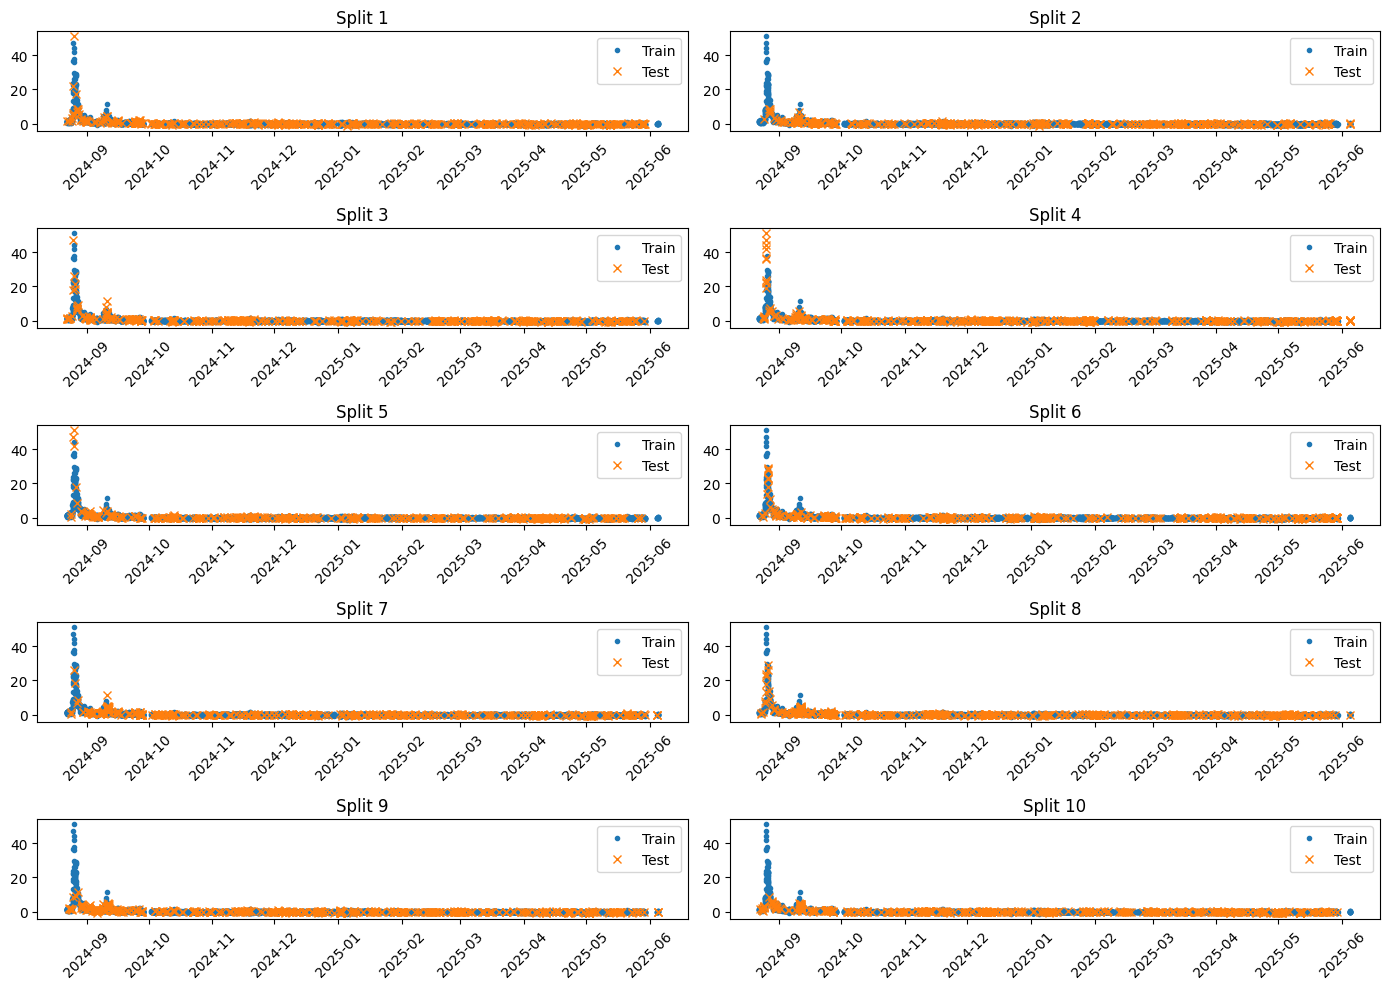

In [8]:
# Artificial-gap CV splits (Irvin et al. 2021 style)
rng = np.random.default_rng(42)

sampling_pmf = learn_gap_dist(data_main[TARGET], n_grid=6, n_mc=20, rng=rng, verbose=True)

splits, coverage = create_artificial_gap_splits(
    target_full=data_main[TARGET],   # full series, real NaNs intact -- NOT X/y
    train_index=X.index,
    sampling_pmf=sampling_pmf,
    n_splits=N_FOLDS,
    eval_frac=0.1,
    rng=rng,
    verbose=True,
)

# optional diagnostic plot
plot_cv_splits(X, y, splits, ncols=2);


# HYPERPARAMETER TUNING

In [9]:
# DEFINE RANGES
if MODEL_TYPE == 'XGBoost':
    # XGBoost: Use continuous distributions for fine-tuning
    PARAM_DIST = {
        'n_estimators': randint(100, 1000),      # Any integer 100-1000
        'max_depth': randint(3, 15),             # Any integer 3-15
        'learning_rate': uniform(0.005, 0.1),    # Any float 0.005-0.105
        'subsample': uniform(0.6, 0.4),          # 0.6 to 1.0
        'colsample_bytree': uniform(0.6, 0.4),   # 0.6 to 1.0
        'min_child_weight': randint(1, 10),
        'gamma': uniform(0, 0.5)
    }
    model = XGBRegressor(n_jobs=-1, random_state=42)

elif MODEL_TYPE == 'RandomForest':
    # RF: Integers for counts/depths
    PARAM_DIST = {
        'n_estimators': randint(100, 500),
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', 1.0]
    }
    model = RandomForestRegressor(n_jobs=-1, random_state=42)

# RUN RANDOM SEARCH
print(f"Starting optimization for {MODEL_TYPE}...")

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=PARAM_DIST,
    n_iter=100,      # number of random tries
    cv=splits,       # list of (train_idx, test_idx) 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

search.fit(X, y)

# RESULTS
print(f"Best RMSE: {-search.best_score_:.4f}")
print("Best Params:", search.best_params_)

Starting optimization for XGBoost...
Fitting 10 folds for each of 100 candidates, totalling 1000 fits


Best RMSE: 0.6329
Best Params: {'colsample_bytree': np.float64(0.8189785227596447), 'gamma': np.float64(0.2254552237080522), 'learning_rate': np.float64(0.09604712784032732), 'max_depth': 9, 'min_child_weight': 3, 'n_estimators': 180, 'subsample': np.float64(0.9798082494630569)}


# EXPORT 

In [10]:
filename = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(filename, "w") as f:
    json.dump(search.best_params_, f)

# **End of notebook**

In [11]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-10-06 16:47:25
